Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Academic_Scores_Avg  \
0                         No            7                            73   
1                         No            8                            59   
2                        Yes            7                            91   
3                        Yes            8                            98   
4                        Yes            6                

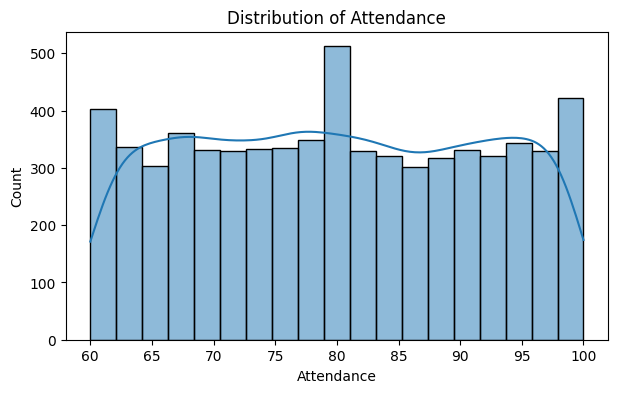

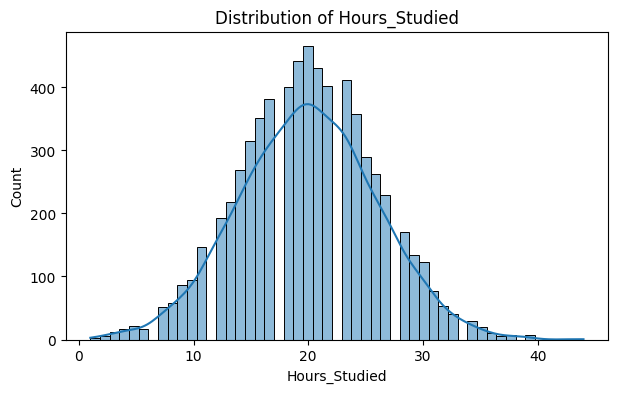

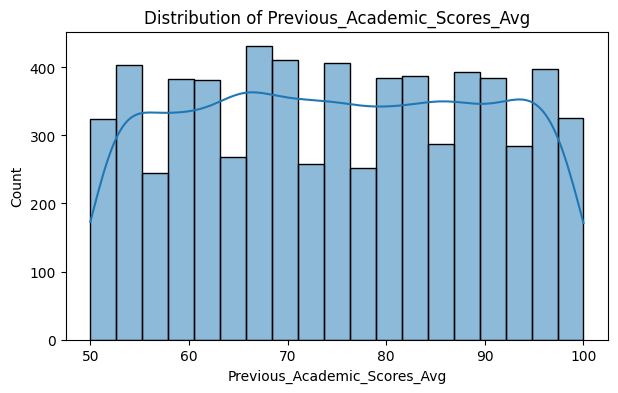

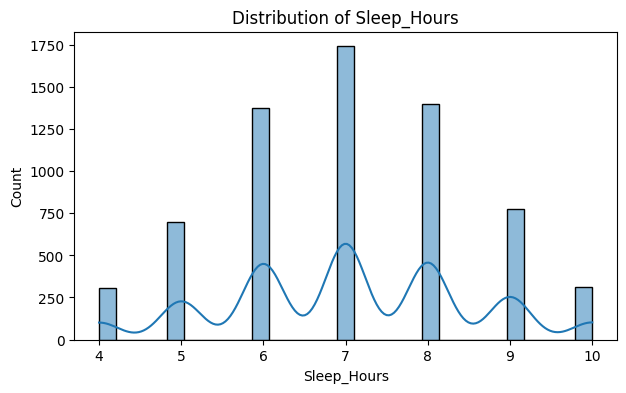

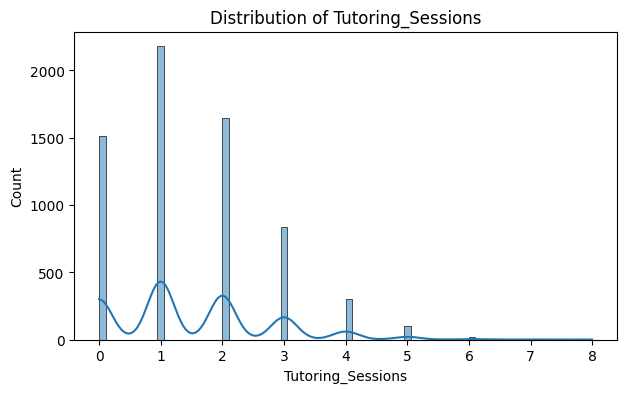

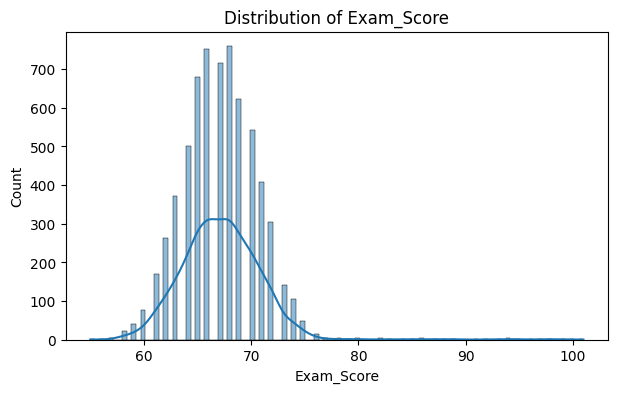

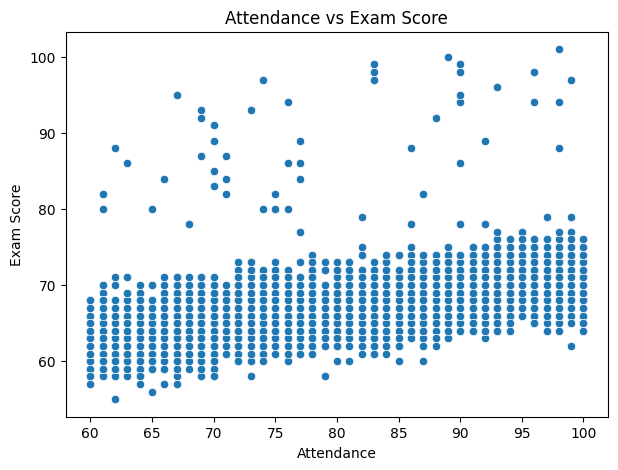

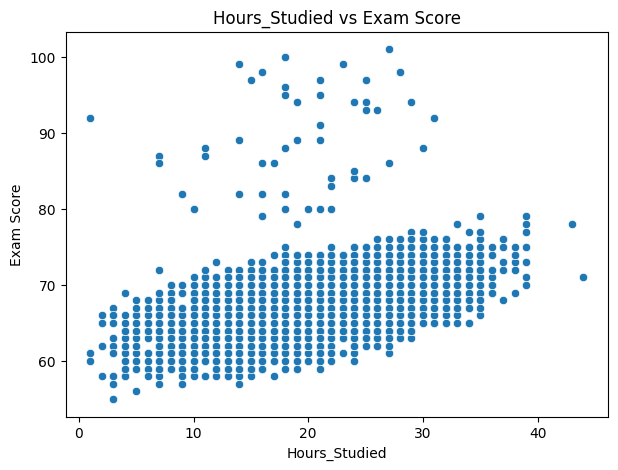

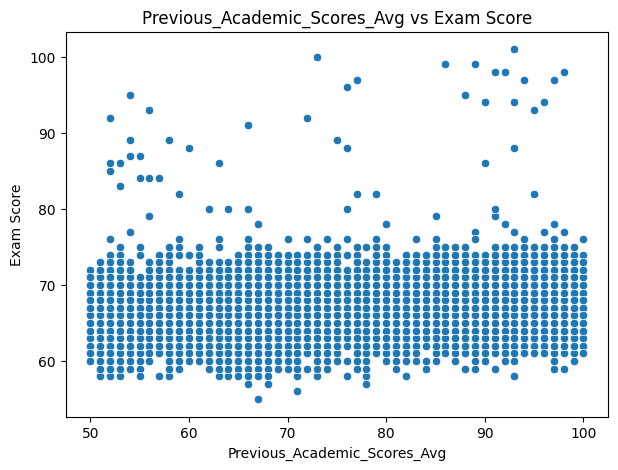

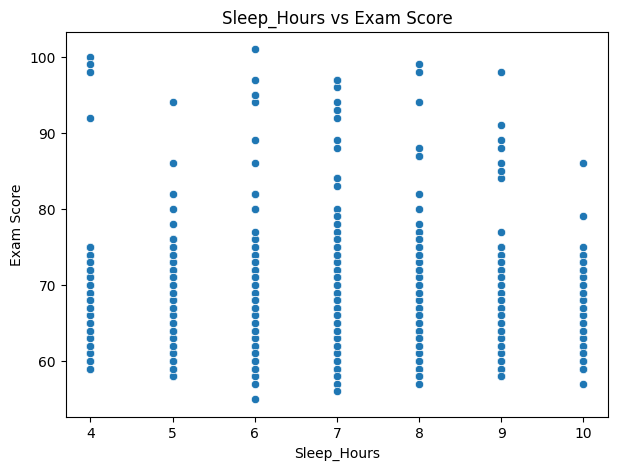

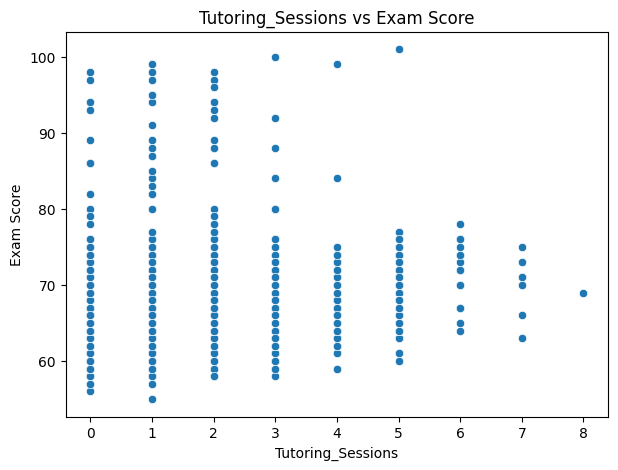

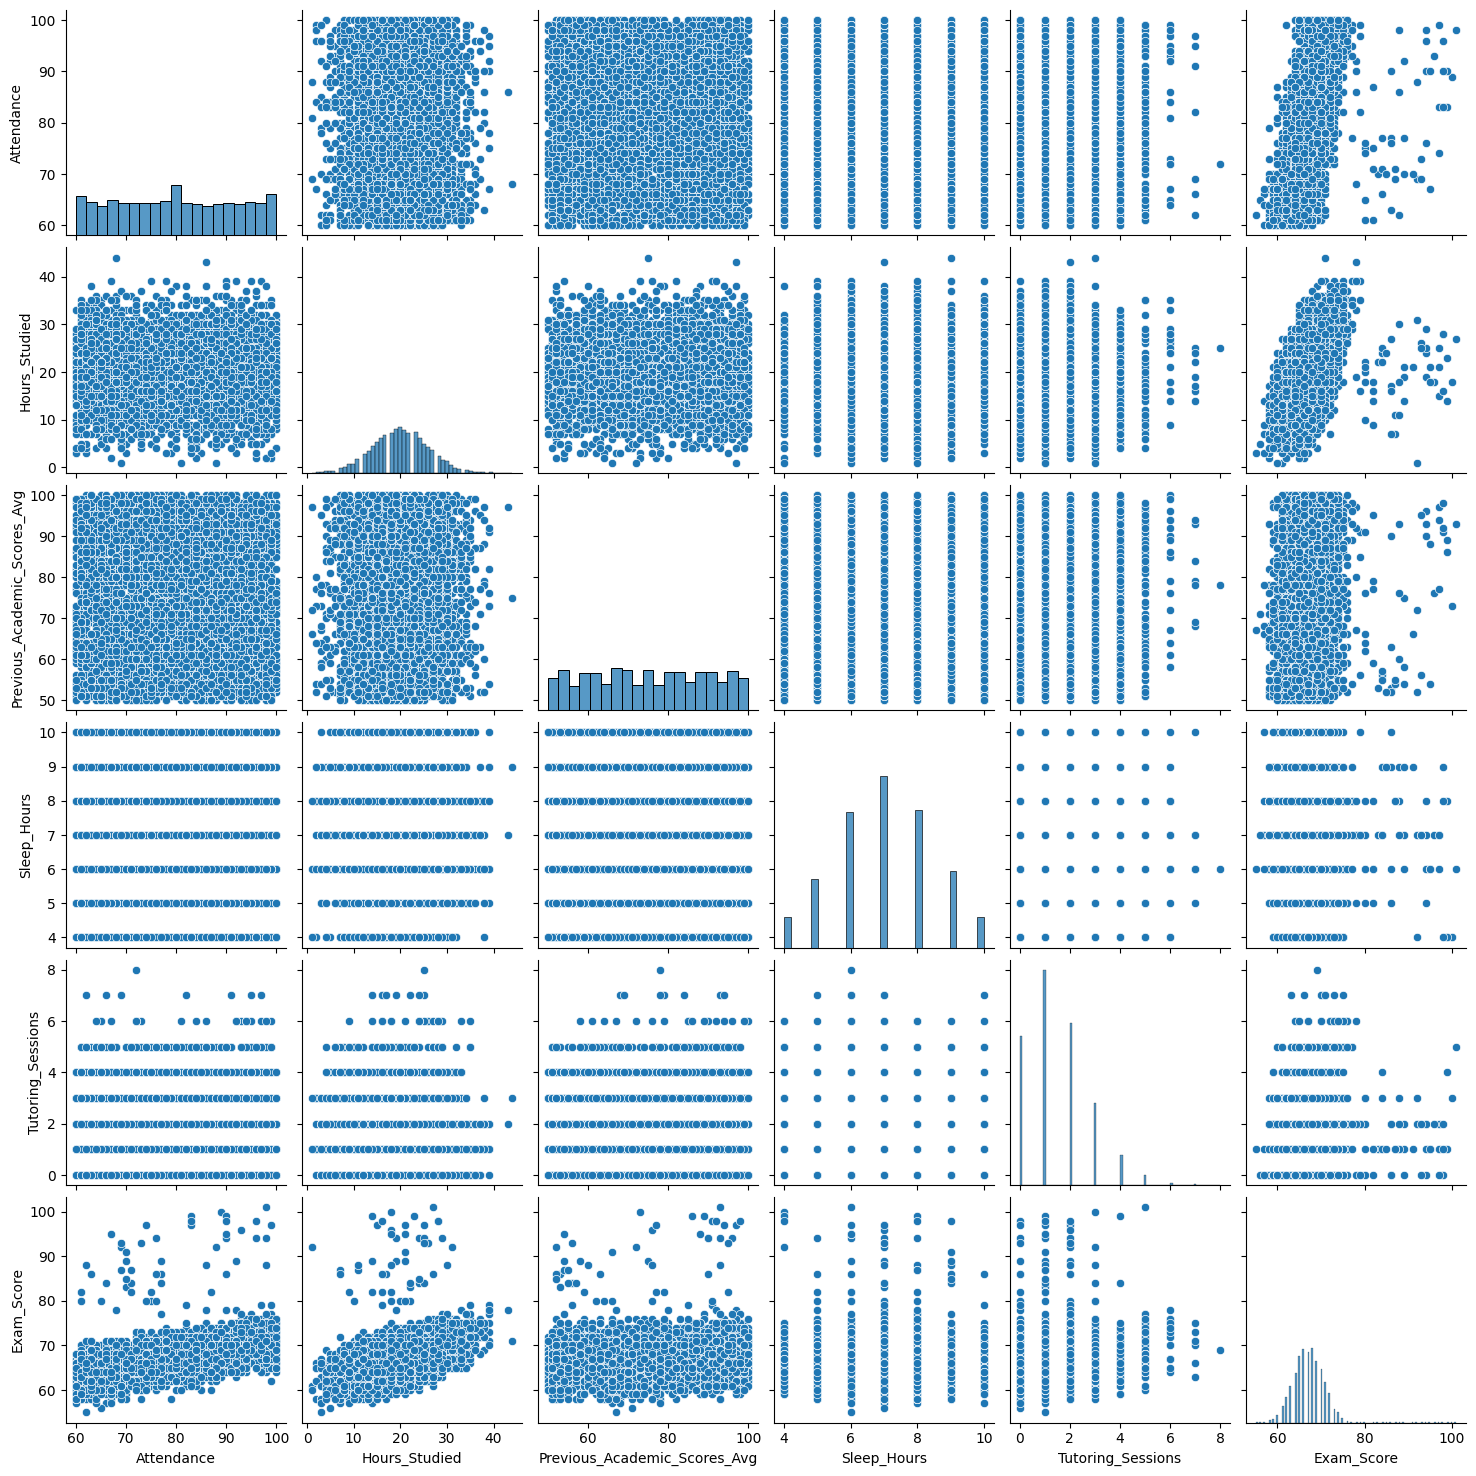

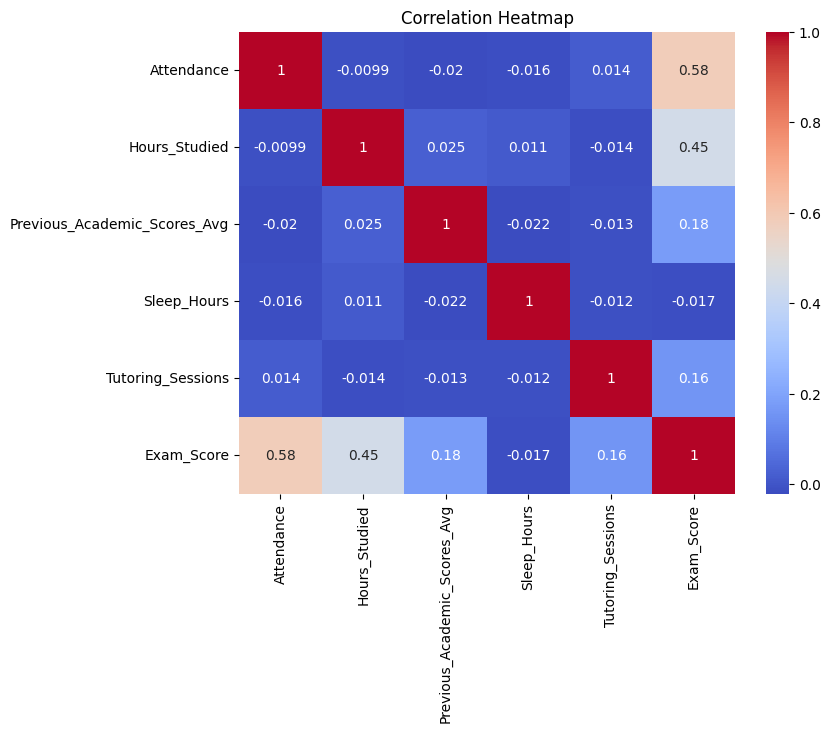


Correlation with Exam Score
Exam_Score                      1.000000
Attendance                      0.581072
Hours_Studied                   0.445455
Previous_Academic_Scores_Avg    0.175079
Tutoring_Sessions               0.156525
Sleep_Hours                    -0.017022
Name: Exam_Score, dtype: float64

Selected Features
   Attendance  Hours_Studied  Previous_Academic_Scores_Avg  Sleep_Hours  \
0          84             23                            73            7   
1          64             19                            59            8   
2          98             24                            91            7   
3          89             29                            98            8   
4          92             19                            65            6   

   Tutoring_Sessions  
0                  0  
1                  2  
2                  2  
3                  1  
4                  3  

Training Data Shape : (5285, 5)
Testing Data Shape  : (1322, 5)

Training Hybrid St

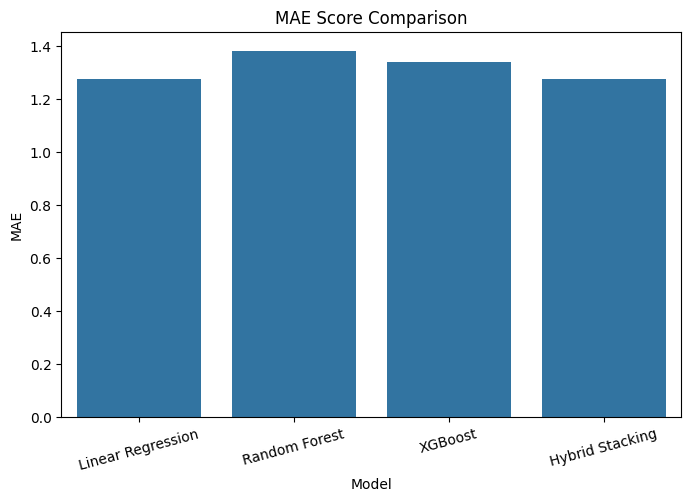

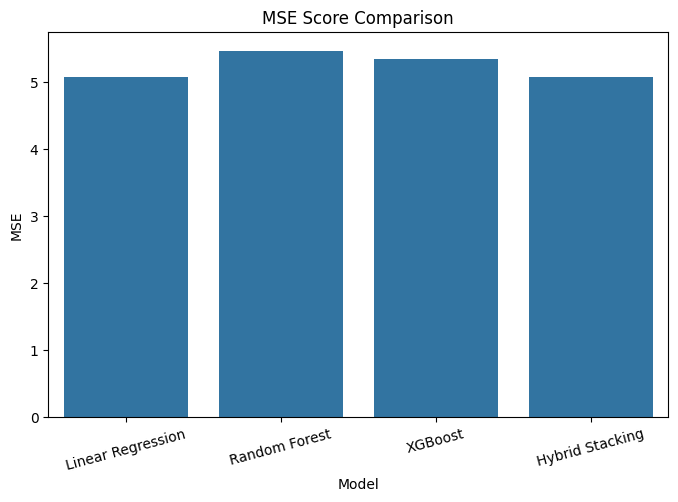

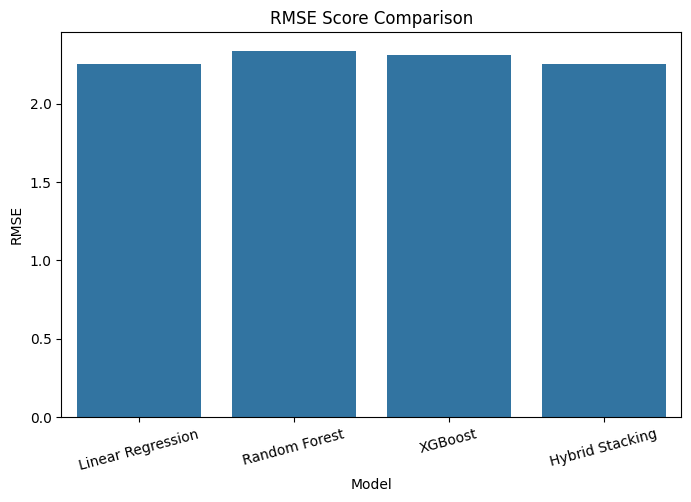

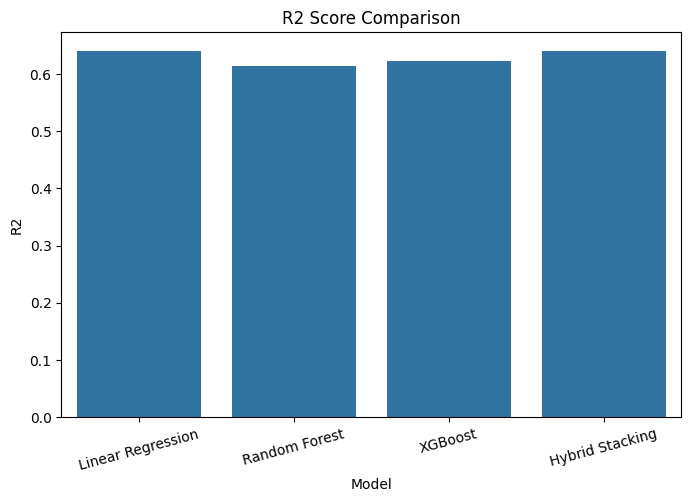

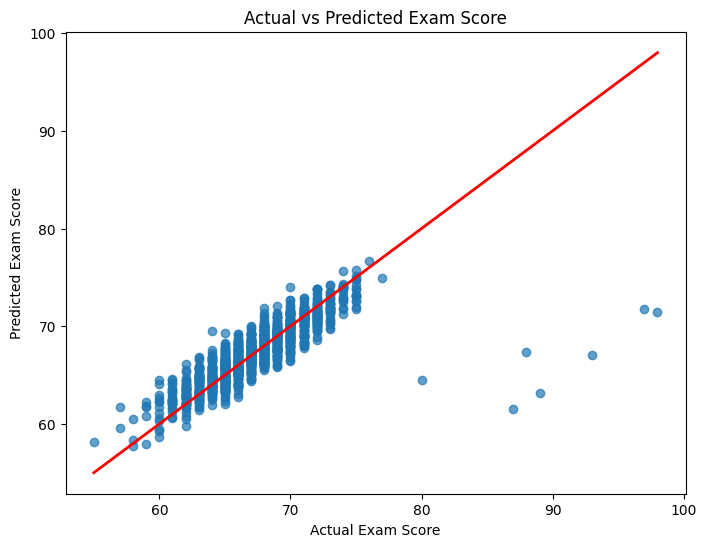


Model Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from google.colab import (drive,files)
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

file_path = "/content/drive/MyDrive/Dataset/StudentPerformanceFactorsDataset.csv"
df = pd.read_csv(file_path)
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.drop_duplicates(inplace=True)
print("\nDataset Shape After Cleaning:", df.shape)

columns = ["Attendance","Hours_Studied","Previous_Academic_Scores_Avg","Sleep_Hours","Tutoring_Sessions","Exam_Score"]
for col in columns:
    plt.figure(figsize=(7,4))
    sns.histplot(
        df[col],
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

features = ["Attendance","Hours_Studied","Previous_Academic_Scores_Avg","Sleep_Hours","Tutoring_Sessions"]
for col in features:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=df[col],
        y=df["Exam_Score"]
    )
    plt.title(f"{col} vs Exam Score")
    plt.xlabel(col)
    plt.ylabel("Exam Score")
    plt.show()

sns.pairplot(
    df[["Attendance","Hours_Studied","Previous_Academic_Scores_Avg","Sleep_Hours","Tutoring_Sessions","Exam_Score"]]
)
plt.show()

selected = df[["Attendance","Hours_Studied","Previous_Academic_Scores_Avg","Sleep_Hours","Tutoring_Sessions","Exam_Score"]]
plt.figure(figsize=(8,6))
sns.heatmap(
    selected.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with Exam Score")
print(selected.corr()["Exam_Score"].sort_values(ascending=False))

X = df[["Attendance","Hours_Studied","Previous_Academic_Scores_Avg","Sleep_Hours","Tutoring_Sessions"]]
y = df["Exam_Score"]
print("\nSelected Features")

print(X.head())

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.20,random_state=42)
print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

results=pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2"])

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.loc[len(results)] = ["Linear Regression",
    mean_absolute_error(y_test, lr_pred),
    mean_squared_error(y_test, lr_pred),
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    r2_score(y_test, lr_pred)]

rf_model = RandomForestRegressor(n_estimators=1000,max_depth=7,min_samples_split=5,min_samples_leaf=3,max_features="sqrt",random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
results.loc[len(results)] = ["Random Forest",
    mean_absolute_error(y_test, rf_pred),
    mean_squared_error(y_test, rf_pred),
    np.sqrt(mean_squared_error(y_test, rf_pred)),
    r2_score(y_test, rf_pred)]

xgb = XGBRegressor(n_estimators=600,learning_rate=0.05,max_depth=3,subsample=0.7,colsample_bytree=0.7,objective="reg:squarederror",random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.loc[len(results)] = ["XGBoost",
    mean_absolute_error(y_test, xgb_pred),
    mean_squared_error(y_test, xgb_pred),
    np.sqrt(mean_squared_error(y_test, xgb_pred)),
    r2_score(y_test, xgb_pred)]

base_models = [("Linear Regression",lr),("Xgb",xgb)]

meta_model = LinearRegression()

model = StackingRegressor(estimators=base_models,final_estimator=meta_model,passthrough=True,cv=5)

print("\nTraining Hybrid Stacking Model...")

model.fit(X_train,y_train)
print("Training Completed Successfully!")

y_pred = model.predict(X_test)

MAE = mean_absolute_error(y_test,y_pred)

MSE = mean_squared_error(y_test,y_pred)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test,y_pred)
print("MODEL PERFORMANCE")
print(f"MAE       : {MAE:.4f}")
print(f"MSE       : {MSE:.4f}")
print(f"RMSE      : {RMSE:.4f}")
print(f"R² Score  : {R2:.4f}")

results.loc[len(results)] = ["Hybrid Stacking",MAE,MSE,RMSE,R2]
print("\nMODEL COMPARISON")
print(results)

plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="MAE")
plt.title("MAE Score Comparison")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="MSE")
plt.title("MSE Score Comparison")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="RMSE")
plt.title("RMSE Score Comparison")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="R2")
plt.title("R2 Score Comparison")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.7)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linewidth=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

pickle.dump(model,open("student_model.pkl","wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(list(X.columns),open("features.pkl","wb"))

print("\nModel Saved Successfully!")

files.download("student_model.pkl")

files.download("scaler.pkl")

files.download("features.pkl")